# Computer Vision Masterclass - Image Segmentation with Mask R-CNN


## Downloading the repository


In [77]:
!git clone https://github.com/alsombra/Mask_RCNN-TF2  # updated repository

fatal: destination path 'Mask_RCNN-TF2' already exists and is not an empty directory.


In [78]:
!pip install tensorflow==2.15.0

DEPRECATION: Loading egg at /usr/local/lib/python3.11/dist-packages/mask_rcnn-2.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [3]:
!pip install numpy==1.26.0

> **Important**: You need to select the option 'Runtime > Restart session'


In [79]:
%cd Mask_RCNN-TF2

/content/Mask_RCNN-TF2


In [80]:
pwd

'/content/Mask_RCNN-TF2'

In [81]:
!pip install -r requirements.txt

DEPRECATION: Loading egg at /usr/local/lib/python3.11/dist-packages/mask_rcnn-2.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [82]:
!python setup.py install

/content/Mask_RCNN-TF2/setup.py:9: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/usr/local/lib/python3.11/dist-packages/setuptools/dist.py:491: SetuptoolsDeprecationWarning: Invalid dash-separated options
!!

        ********************************************************************************
        Usage of dash-separated 'description-file' will not be supported in future
        versions. Please use the underscore name 'description_file' instead.

        This deprecation is overdue, please update your project and remove deprecated
        calls to avoid build errors in the future.

        See https://setuptools.pypa.io/en/latest/userguide/declarative_config.html for details.
        ********************************************************************************

!!
  opt = self.warn_dash_deprecation(opt, section)
/usr/local/lib/python3.11/dist-packages/setuptools/dist.py:491: Setu

In [83]:
%cd ..

/content


In [84]:
pwd

'/content'

## Importing the libraries


In [85]:
import os
import sys
import cv2
import numpy as np
import skimage.io
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [86]:
np.__version__

'1.26.0'

In [87]:
import tensorflow as tf

In [88]:
tf.__version__

'2.15.0'

In [89]:
ROOT_DIR = os.path.abspath('./Mask_RCNN-TF2')
ROOT_DIR

'/content/Mask_RCNN-TF2'

In [90]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/Mask_RCNN-TF2',
 '/',
 '/content/Mask_RCNN-TF2/samples/coco/',
 '/']

In [91]:
sys.path.append(ROOT_DIR)

In [92]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/Mask_RCNN-TF2',
 '/',
 '/content/Mask_RCNN-TF2/samples/coco/',
 '/',
 '/content/Mask_RCNN-TF2']

In [93]:
from mrcnn import utils
from mrcnn import visualize
import mrcnn.model as modellib

In [94]:
# https://cocodataset.org/#home
sys.path.append(os.path.join(ROOT_DIR, 'samples/coco/'))

In [95]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/Mask_RCNN-TF2',
 '/',
 '/content/Mask_RCNN-TF2/samples/coco/',
 '/',
 '/content/Mask_RCNN-TF2',
 '/content/Mask_RCNN-TF2/samples/coco/']

In [96]:
import coco

In [97]:
MODEL_DIR = os.path.join(ROOT_DIR, 'logs')
IMAGE_DIR = os.path.join(ROOT_DIR, 'images')

In [98]:
MODEL_DIR, IMAGE_DIR

('/content/Mask_RCNN-TF2/logs', '/content/Mask_RCNN-TF2/images')

### [ ! ] Compatibility Update

Run the 5 lines below so we don't have any issues when running with the latest versions of Tensorflow


In [99]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

/usr/local/lib/python3.11/dist-packages/tensorflow/python/client/session.py:1793: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


## Loading the pre-trained neural network


In [100]:
COCO_MODEL_PATH = os.path.join(ROOT_DIR, 'mask_rcnn_coco.h5')

In [101]:
utils.download_trained_weights(COCO_MODEL_PATH)

... done downloading pretrained model!


In [102]:
class InferenceConfig(coco.CocoConfig):
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1

In [103]:
config = InferenceConfig()

In [104]:
config.display()


Configurations:
BACKBONE                       resnet101
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        100
DETECTION_MIN_CONFIDENCE       0.7
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  1024
IMAGE_META_SIZE                93
IMAGE_MIN_DIM                  800
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [1024 1024    3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE         

In [105]:
MODEL_DIR

'/content/Mask_RCNN-TF2/logs'

In [106]:
network = modellib.MaskRCNN(
    mode='inference', model_dir=MODEL_DIR, config=config)

In [107]:
network.load_weights(COCO_MODEL_PATH, by_name=True)

## Detecting objects


In [108]:
class_names = ['BG', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
               'bus', 'train', 'truck', 'boat', 'traffic light',
               'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird',
               'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear',
               'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie',
               'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
               'kite', 'baseball bat', 'baseball glove', 'skateboard',
               'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
               'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
               'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
               'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
               'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
               'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
               'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
               'teddy bear', 'hair drier', 'toothbrush']

In [109]:
len(class_names)

81

In [110]:
class_names[1], class_names.index('person')

('person', 1)

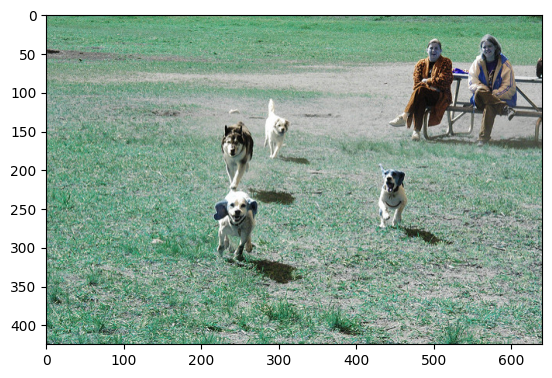

In [111]:
image2 = cv2.imread(
    '/content/Mask_RCNN-TF2/images/2516944023_d00345997d_z.jpg')
plt.imshow(image2)  # BGR

In [112]:
image = skimage.io.imread(
    '/content/Mask_RCNN-TF2/images/2516944023_d00345997d_z.jpg')  # RGB

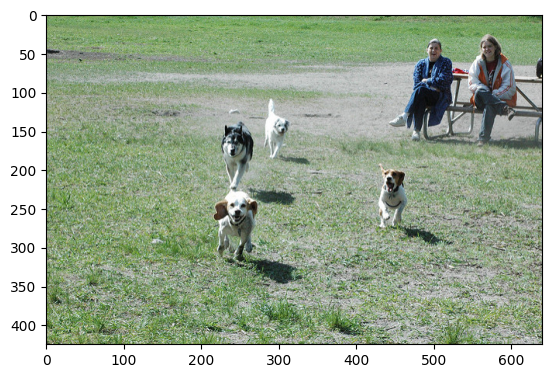

In [113]:
plt.imshow(image)

In [114]:
class_names[17], class_names[1], class_names[14]

('dog', 'person', 'bench')

In [41]:
import numpy as np
if not hasattr(np, 'bool'):
    np.bool = np.bool_

/tmp/ipython-input-41-629143025.py:2: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [42]:
results = network.detect([image], verbose=0)
results

[{'rois': array([[195, 426, 277, 467],
         [226, 216, 321, 273],
         [106, 280, 189, 314],
         [ 32, 445, 159, 527],
         [136, 225, 231, 268],
         [ 27, 541, 168, 607],
         [ 75, 476, 164, 634]], dtype=int32),
  'class_ids': array([17, 17, 17,  1, 17,  1, 14], dtype=int32),
  'scores': array([0.9997003 , 0.9996582 , 0.999605  , 0.9991323 , 0.9979928 ,
         0.99743587, 0.9165014 ], dtype=float32),
  'masks': array([[[False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False],
          ...,
          [False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False]],
  
         [[False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False],
          [False, False, False, ..., False, False, False],
       

In [43]:
r = results[0]

In [44]:
visualize.display_instances(image, r['rois'], r['masks'],
                            r['class_ids'], class_names, r['scores'])

Output hidden; open in https://colab.research.google.com to view.

## Removing the background


In [45]:
np.unique(r['masks'], return_counts=True)

(array([False,  True]), array([1881592,   22408]))

In [46]:
r['masks']

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [47]:
def segment(image, r, index):
    mask = r['masks'][:, :, index]
    # print(mask)
    # print(mask.shape)

    mask = np.stack((mask,) * 3, axis=-1)
    # print(mask)
    # print(mask.shape)

    mask = mask.astype('uint8')
    # print(mask)
    bg = 255 - mask * 255
    # print(mask, mask.min(), mask.max())

    mask_show = np.invert(bg)
    # print(mask_show)
    mask_img = image * mask
    # print(mask_img)

    result = mask_img + bg
    return result, mask_show

In [48]:
image.shape, 425 * 640

((425, 640, 3), 272000)

In [49]:
segmentation, mask_obj = segment(image, r, 0)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
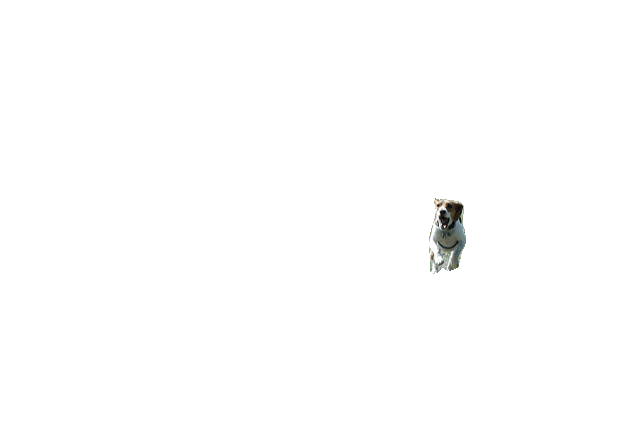

In [50]:
segmentation

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
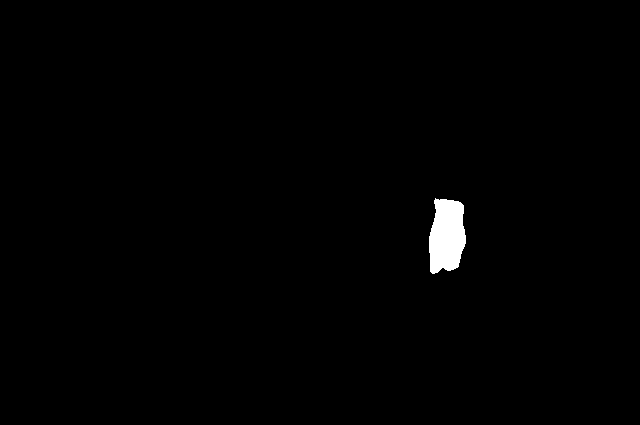

In [51]:
mask_obj

In [52]:
def show_segment(image, r, index, show_mask=False):
    segmentation, mask_obj = segment(image, r, index)
    plt.subplots(1, figsize=(16, 16))
    plt.axis('off')
    if show_mask == True:
        plt.imshow(np.concatenate([mask_obj, segmentation], axis=1))
    else:
        plt.imshow(np.concatenate([image, segmentation], axis=1))

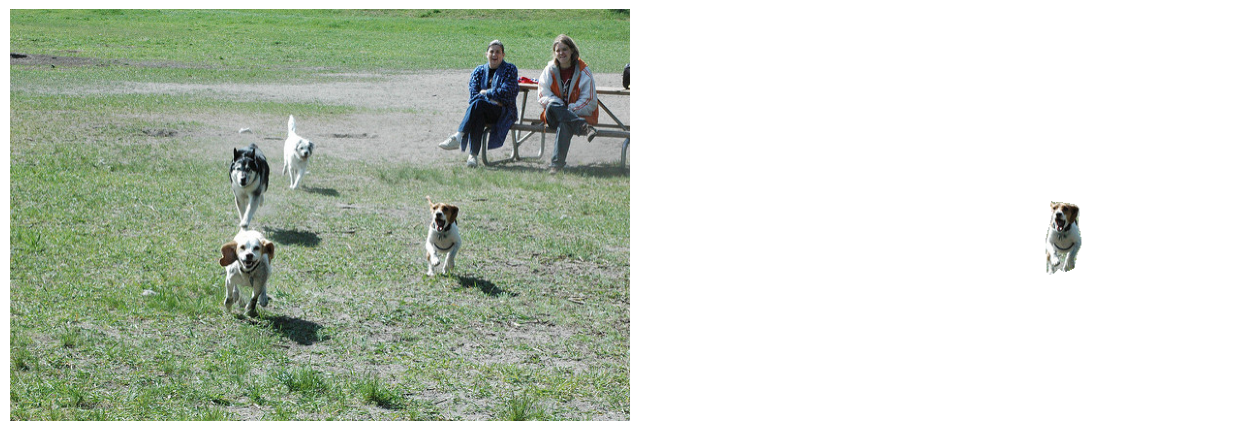

In [53]:
show_segment(image, r, 0, False)

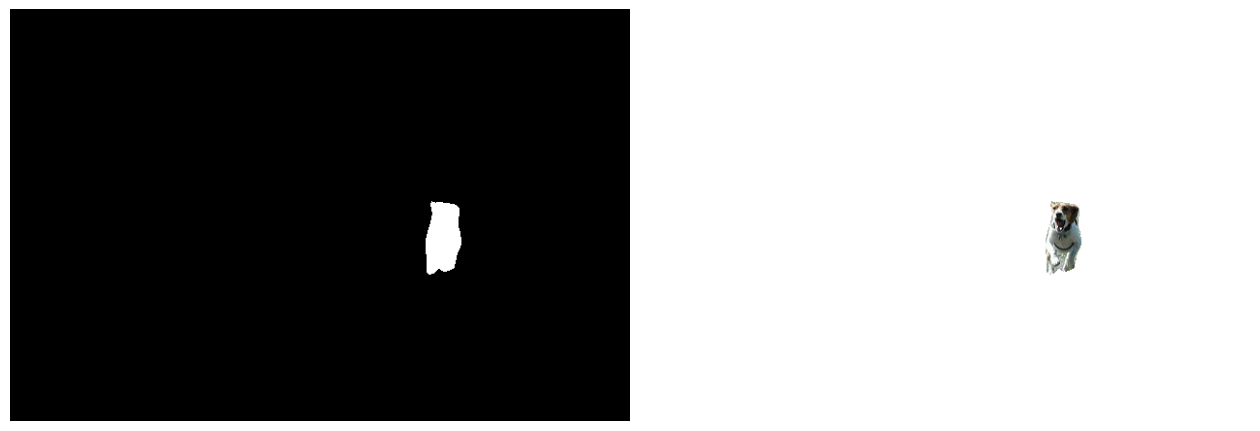

In [54]:
show_segment(image, r, 0, True)

In [55]:
r['rois'], len(r['rois'])

(array([[195, 426, 277, 467],
        [226, 216, 321, 273],
        [106, 280, 189, 314],
        [ 32, 445, 159, 527],
        [136, 225, 231, 268],
        [ 27, 541, 168, 607],
        [ 75, 476, 164, 634]], dtype=int32),
 7)

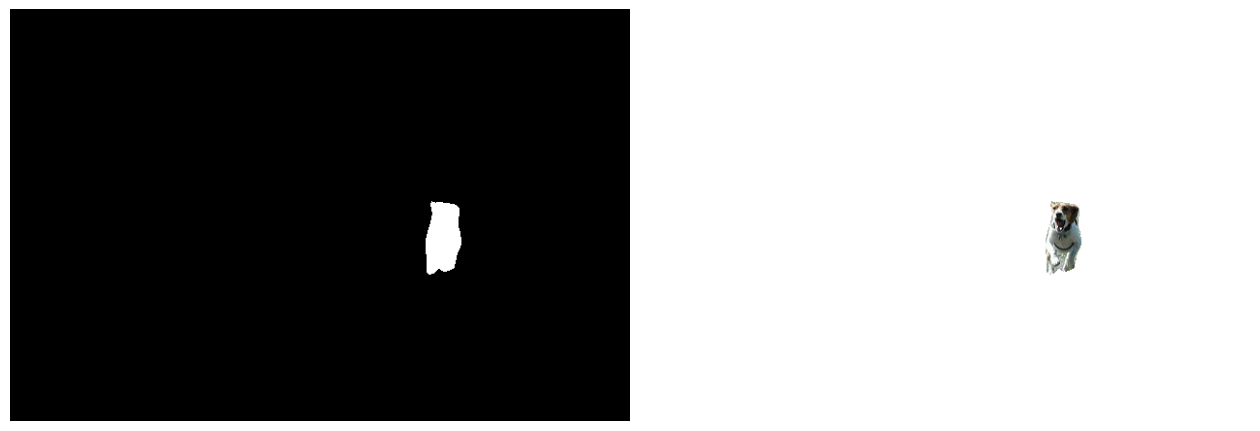

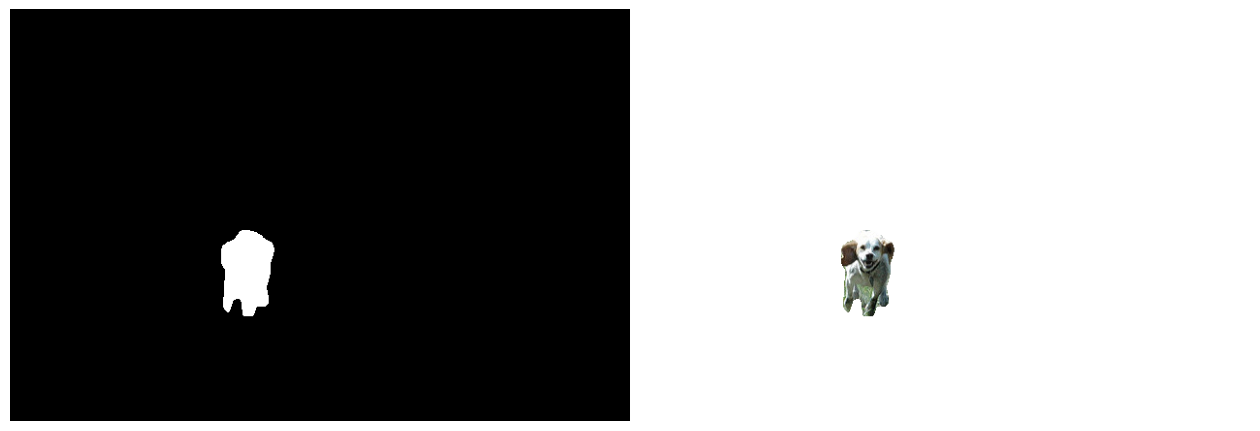

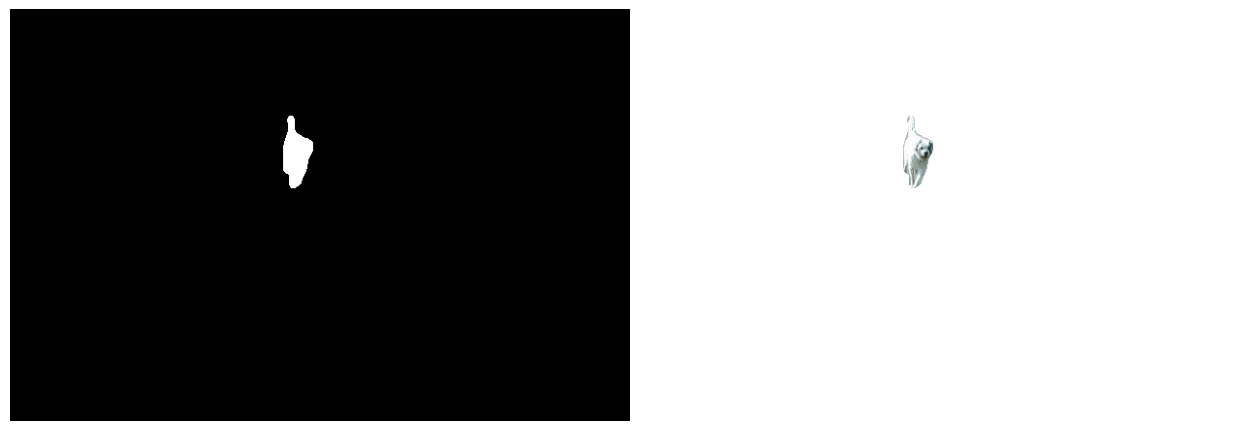

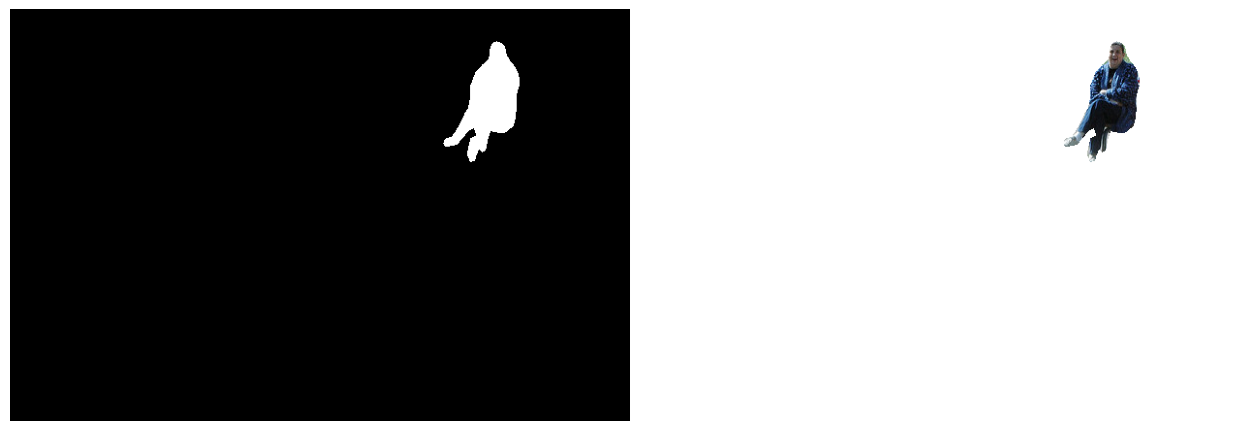

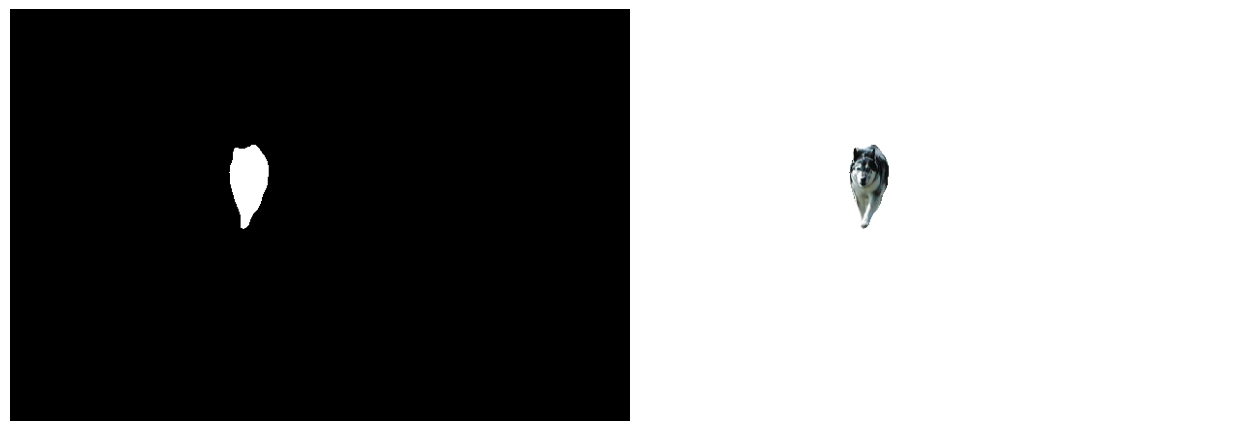

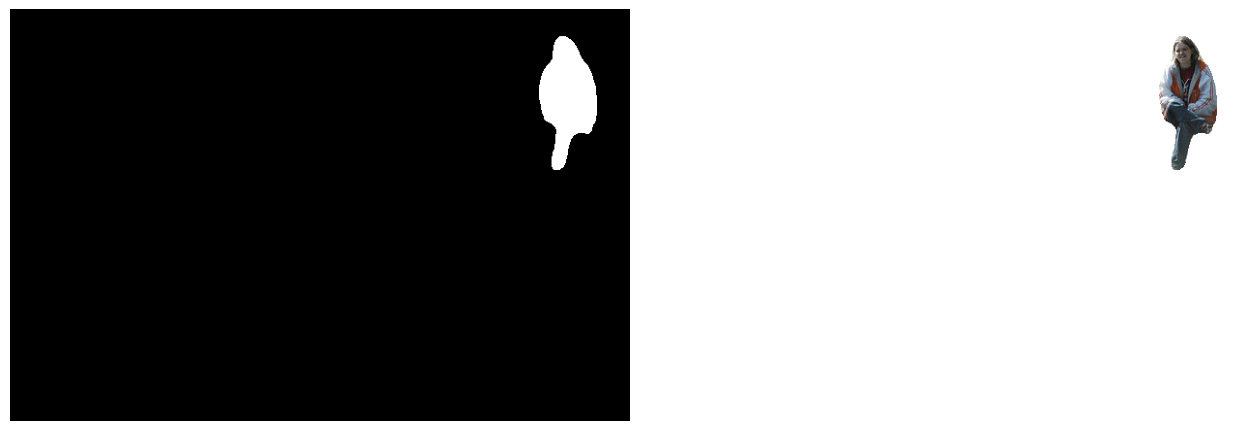

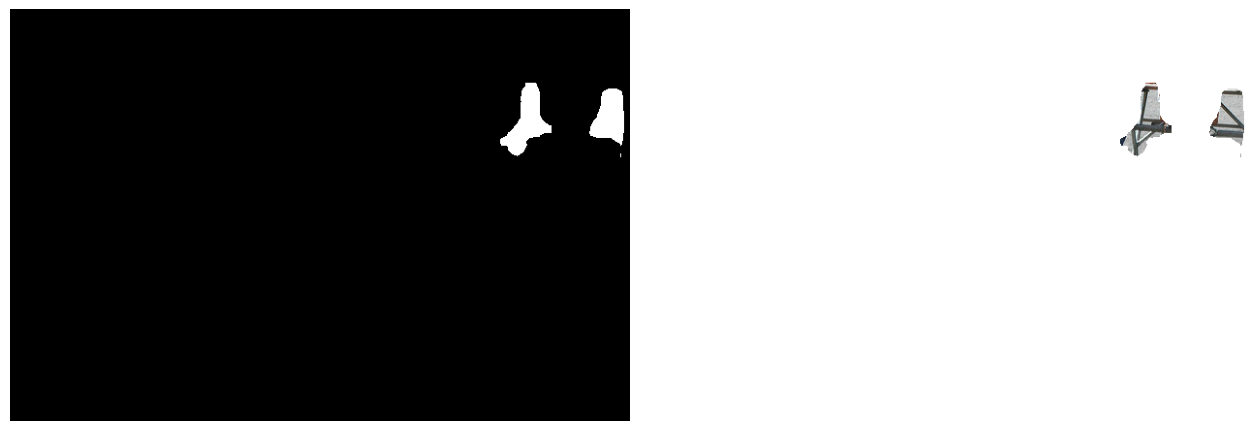

In [56]:
for index in range(len(r['rois'])):
    show_segment(image, r, index, True)

## Segmentation in videos


In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
capture = cv2.VideoCapture(
    '/content/drive/MyDrive/Computer-Vision/Videos/video_street2.mp4')
connected, frame = capture.read()
connected

True

In [118]:
frame.shape

(720, 1280, 3)

In [119]:
save_video = cv2.VideoWriter('/content/drive/MyDrive/Computer-Vision/Videos/video_street2_result_seg.avi',
                             cv2.VideoWriter_fourcc(*'XVID'), 24, (frame.shape[1], frame.shape[0]))

In [120]:
!cp /content/drive/MyDrive/Computer-Vision/PyCharm/video_functions.py ./Mask_RCNN-TF2/mrcnn

In [121]:
from mrcnn import video_functions

In [122]:
colors = video_functions.random_colors(len(class_names), 55)
len(colors)

81

In [123]:
print(colors)

[(0.518518518518519, 0.0, 1.0), (1.0, 0.0, 0.14814814814814792), (0.37037037037037046, 1.0, 0.0), (0.0, 1.0, 0.5185185185185182), (1.0, 0.0, 0.5925925925925926), (1.0, 0.0, 0.518518518518519), (1.0, 0.0, 0.7407407407407405), (1.0, 0.5925925925925926, 0.0), (0.0, 1.0, 0.2962962962962963), (0.0, 1.0, 0.7407407407407405), (0.6666666666666667, 1.0, 0.0), (1.0, 0.07407407407407407, 0.0), (0.5925925925925926, 0.0, 1.0), (0.0, 0.5185185185185182, 1.0), (0.0, 1.0, 0.4444444444444442), (0.8888888888888884, 0.0, 1.0), (0.8888888888888888, 1.0, 0.0), (0.0, 0.8888888888888893, 1.0), (1.0, 0.2962962962962963, 0.0), (0.0, 0.2962962962962967, 1.0), (0.0740740740740744, 0.0, 1.0), (0.9629629629629628, 0.0, 1.0), (0.22222222222222232, 0.0, 1.0), (0.7407407407407409, 1.0, 0.0), (1.0, 0.6666666666666666, 0.0), (0.0, 1.0, 0.22222222222222232), (0.0, 1.0, 0.07407407407407396), (0.0, 1.0, 0.5925925925925926), (0.0, 0.44444444444444464, 1.0), (0.0, 0.8148148148148149, 1.0), (1.0, 0.5185185185185185, 0.0), (0

In [124]:
def show(img):
    fig = plt.gcf()
    fig.set_size_inches(16, 10)
    plt.axis('off')
    plt.imshow(img)
    plt.show()

In [125]:
frame_show = 20
current_frame = 0

In [126]:
while True:
    connected, frame = capture.read()
    if not connected:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = network.detect([rgb_frame], verbose=0)
    r = results[0]

    processed_frame = video_functions.display_instances(
        frame, r['rois'], r['masks'],
        r['class_ids'], class_names, r['scores'], colors=colors
    )

    if current_frame < frame_show:
        show(cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB))
        current_frame += 1

    save_video.write(processed_frame)

    if current_frame >= frame_show:
        break

save_video.release()
capture.release()

Output hidden; open in https://colab.research.google.com to view.

## Homework


In [71]:
images = [os.path.join('/content/Mask_RCNN-TF2/images', f)
          for f in os.listdir('/content/Mask_RCNN-TF2/images')]
images

['/content/Mask_RCNN-TF2/images/2383514521_1fc8d7b0de_z.jpg',
 '/content/Mask_RCNN-TF2/images/8829708882_48f263491e_z.jpg',
 '/content/Mask_RCNN-TF2/images/3651581213_f81963d1dd_z.jpg',
 '/content/Mask_RCNN-TF2/images/1045023827_4ec3e8ba5c_z.jpg',
 '/content/Mask_RCNN-TF2/images/2516944023_d00345997d_z.jpg',
 '/content/Mask_RCNN-TF2/images/9247489789_132c0d534a_z.jpg',
 '/content/Mask_RCNN-TF2/images/3627527276_6fe8cd9bfe_z.jpg',
 '/content/Mask_RCNN-TF2/images/12283150_12d37e6389_z.jpg',
 '/content/Mask_RCNN-TF2/images/6821351586_59aa0dc110_z.jpg',
 '/content/Mask_RCNN-TF2/images/5951960966_d4e1cda5d0_z.jpg',
 '/content/Mask_RCNN-TF2/images/6584515005_fce9cec486_z.jpg',
 '/content/Mask_RCNN-TF2/images/9118579087_f9ffa19e63_z.jpg',
 '/content/Mask_RCNN-TF2/images/8734543718_37f6b8bd45_z.jpg',
 '/content/Mask_RCNN-TF2/images/3878153025_8fde829928_z.jpg',
 '/content/Mask_RCNN-TF2/images/25691390_f9944f61b5_z.jpg',
 '/content/Mask_RCNN-TF2/images/3800883468_12af3c0b50_z.jpg',
 '/content/M

In [72]:
for image in images:
    # try:
    current_image = skimage.io.imread(image)
    (H, W) = current_image.shape[:2]
    # except:
    #  continue

    results = network.detect([current_image], verbose=0)
    r = results[0]
    visualize.display_instances(current_image, r['rois'], r['masks'],
                                r['class_ids'], class_names, r['scores'])

Output hidden; open in https://colab.research.google.com to view.